In [ ]:
!pip install umap-learn -q

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.preprocessing import StandardScaler, LabelEncoder

import joblib

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [ ]:
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Now try changing the directory
os.chdir('/content/drive/MyDrive/mtech_project')
!pwd

Mounted at /content/drive
/content/drive/MyDrive/mtech_project


In [ ]:
data_dir = os.path.join(os.getcwd(), 'data')
src_dir = os.path.join(os.getcwd(), 'src')
fig_dir = os.path.join(data_dir, 'figures')
checkpoint_dir = os.path.join(os.getcwd(), 'checkpoints')
dirs_to_make = [
    data_dir,
    os.path.join(data_dir, 'raw'),
    os.path.join(data_dir, 'processed'),
    os.path.join(data_dir, 'train'),
    os.path.join(data_dir, 'val'),
    os.path.join(data_dir, 'test'),
    src_dir,
    fig_dir,
    checkpoint_dir,
]
for d in dirs_to_make:
    if not os.path.exists(d):
        os.makedirs(d)

In [ ]:
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

LOADING TRAINING DATA

In [ ]:
!ls {train_dir}

 scaffold_protbert_E3_train_embeddings.npy   scaffold_train_e3_descriptors.csv
 scaffold_protbert_train_embeddings1.npy     scaffold_train_fingerprints.csv
 scaffold_protbert_train_embeddings.npy      scaffold_train_protein_descriptors.csv
 scaffold_train_data.csv		    'Untitled folder'
 scaffold_train_descriptors.csv


In [ ]:
df = pd.read_csv(os.path.join(train_dir, 'scaffold_train_data.csv'))
df

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity
0,P10275,Cc1cc([C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H...,VHL,22Rv1,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
1,Q05397,COc1cc(C(=O)NCCOCCOCCOCCC(=O)Nc2cccc3c2C(=O)N(...,CRBN,HUH-1,MAAAYLDPNLNHTPNSSTKTHLGTGMERSPGAMERVLKVFHYFESN...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
2,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,293T,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
3,Q96SW2,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,HEK293T,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
4,P09874,O=C(CCCCCCCCCCC(=O)N1CCN(C(=O)c2cc(Cc3n[nH]c(=...,CRBN,MDA-MB-468,MAESSDKLYRVEYAKSGRASCKKCSESIPKDSLRMAIMVQSPMFDG...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True
...,...,...,...,...,...,...,...,...
391,Q9UBN7,O=C(CCCCCCC(=O)N/N=C/c1ccc(OCCOCCOCCn2cc(CNc3c...,CRBN,MCF-7,MTSTGQDSTTTRQRRSRQNPQSPPQDSSVTSKRNIKKGAVPRSIPN...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
392,Q06187,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCN(CCOC...,CRBN,NAMALWA,MAAVILESIFLKRSQQKKKTSPLNFKKRLFLLTVHKLSYYEYDFER...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True
393,P51531,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,A549,MSTPTDPGAMPHPGPSPGPGPSPGPILGPSPGPGPSPGSVHSMMGP...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
394,O60885,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,HeLa,MSAESGPGTRLRNLPVMGDGLETSQMSTTQAQAQPQPANAASTNPP...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True


In [ ]:
df['Uniprot'].value_counts()

,count
Uniprot,
P10275,61
Q06187,40
Q05397,34
P33981,28
O60885,27
P00533,21
Q9UHD2,18
Q96SW2,12
Q07817,11


In [ ]:
# @title Encode the 'Activity' column
df['activity_encoded'] = df['Activity'].astype(int)
df.head()

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity,activity_encoded
0,P10275,Cc1cc([C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H...,VHL,22Rv1,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,1
1,Q05397,COc1cc(C(=O)NCCOCCOCCOCCC(=O)Nc2cccc3c2C(=O)N(...,CRBN,HUH-1,MAAAYLDPNLNHTPNSSTKTHLGTGMERSPGAMERVLKVFHYFESN...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False,0
2,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,293T,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,1
3,Q96SW2,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,HEK293T,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,1
4,P09874,O=C(CCCCCCCCCCC(=O)N1CCN(C(=O)c2cc(Cc3n[nH]c(=...,CRBN,MDA-MB-468,MAESSDKLYRVEYAKSGRASCKKCSESIPKDSLRMAIMVQSPMFDG...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True,1


Loading Descriptors and Fingerprints
Descriptors and fingerprints are loaded and
then combined to form a net dataframe norm_sm_desc_fps, then,
it is normalized using standard scaler

In [ ]:
sm_desc = pd.read_csv(os.path.join(train_dir, 'scaffold_train_descriptors.csv'))
sm_desc.shape

(396, 39)

In [ ]:
sm_desc

,SMR_VSA9,fr_NH0,fr_piperzine,NumRotatableBonds,SlogP_VSA3,BCUT2D_MWHI,EState_VSA10,PEOE_VSA14,fr_Al_OH_noTert,NumHDonors,SlogP_VSA8,Kappa2,NumSaturatedRings,BCUT2D_CHGLO,Kappa3,SPS,PEOE_VSA3,qed,PEOE_VSA1,BCUT2D_MRHI,fr_Al_OH,SMR_VSA1,NumSaturatedHeterocycles,BalabanJ,VSA_EState3,NumAliphaticRings,EState_VSA2,NumAliphaticHeterocycles,SlogP_VSA10,SMR_VSA6,fr_sulfonamd,SlogP_VSA7,EState_VSA8,fr_piperdine,NHOHCount,fr_aniline,fr_COO2,fr_Al_COO,fr_COO
0,23.659602,4,0,12,14.383612,35.495694,29.546568,0.000000,1,3,0.000000,19.754091,3,-2.626166,10.281640,777,0.000000,0.122614,34.799882,6.314115,1,33.544634,2,0.920422,30.521505,3,61.089558,2,0.000000,19.634269,0,5.022633,61.395279,1,3,0,0,0,0
1,17.379012,3,0,20,41.191321,19.413235,46.733005,6.176299,0,4,0.000000,20.684355,1,-2.274009,10.787273,777,4.983979,0.071055,39.634681,6.257953,0,70.417320,1,0.782917,10.268766,3,128.728521,2,30.494357,63.929423,0,0.000000,31.235111,1,4,3,0,0,0
2,10.440599,7,2,29,43.775556,35.495698,59.086052,5.508331,1,5,16.013703,36.572548,4,-2.440802,21.647491,777,26.541667,0.021581,40.493485,7.989801,1,63.822915,4,0.637430,20.454857,5,60.549043,4,24.546018,120.809906,1,5.022633,59.590455,0,5,2,0,0,0
3,10.440599,3,0,21,35.311980,32.133484,43.462825,0.000000,1,6,10.440599,22.455427,2,-2.350035,12.451189,777,4.983979,0.064853,31.273592,7.129660,1,43.462825,2,0.832313,24.433762,3,80.073178,3,5.687386,24.951058,0,0.000000,31.567922,1,6,1,0,0,0
4,0.000000,4,1,19,25.598970,19.142208,42.746713,0.000000,0,4,10.772448,21.060952,2,-2.346510,10.691854,777,9.489097,0.076744,20.433397,6.251700,0,37.952175,2,0.717169,16.111364,3,46.905624,3,10.077801,44.585327,0,0.000000,26.147729,1,4,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,5.749512,5,0,23,41.741387,16.542704,28.767223,0.000000,0,5,0.000000,21.148488,1,-2.274095,11.974744,777,15.587691,0.030323,19.527377,6.251332,0,48.185065,1,0.899297,26.056284,2,42.841304,2,5.687386,38.351198,0,0.000000,31.472843,1,5,1,0,0,0
392,22.756403,6,0,14,23.857337,16.524216,23.972686,0.000000,0,3,22.290781,16.889217,2,-2.315534,8.131808,777,14.649760,0.108638,30.160955,6.235425,0,38.183275,2,0.757665,10.586501,3,43.224151,3,11.505249,57.112253,0,0.000000,25.501444,2,4,2,0,0,0
393,33.197002,6,1,15,33.893946,32.133484,28.987081,0.000000,1,5,21.697978,19.540064,3,-2.360215,10.817360,777,13.764809,0.087814,41.116982,7.129690,1,38.114359,2,0.885816,34.849787,3,50.525592,2,20.286079,49.964241,0,0.000000,35.614739,0,6,2,0,0,0
394,15.441681,6,0,17,35.196631,35.495694,24.284676,0.000000,1,4,15.441681,21.071067,1,-2.349268,11.238475,777,4.983979,0.085325,35.430529,7.148034,1,33.758402,1,0.851554,29.600691,2,70.717800,2,0.000000,39.517041,0,5.022633,44.979182,0,4,0,0,0,0


In [ ]:
sm_fps = pd.read_csv(os.path.join(train_dir, 'scaffold_train_fingerprints.csv'))
sm_fps.shape

(396, 2048)

In [ ]:
sm_desc_fps = pd.concat([sm_desc, sm_fps], axis=1)
sm_desc_fps.shape

(396, 2087)

In [ ]:
sm_desc_fps = sm_desc_fps.drop(columns=['SPS'])
sm_desc_fps.shape

(396, 2086)

In [ ]:
sm_desc_fps.head()

SMR_VSA9  fr_NH0  fr_piperzine  NumRotatableBonds  SlogP_VSA3  \
0  23.659602       4             0                 12   14.383612   
1  17.379012       3             0                 20   41.191321   
2  10.440599       7             2                 29   43.775556   
3  10.440599       3             0                 21   35.311980   
4   0.000000       4             1                 19   25.598970   

   BCUT2D_MWHI  EState_VSA10  PEOE_VSA14  fr_Al_OH_noTert  NumHDonors  \
0    35.495694     29.546568    0.000000                1           3   
1    19.413235     46.733005    6.176299                0           4   
2    35.495698     59.086052    5.508331                1           5   
3    32.133484     43.462825    0.000000                1           6   
4    19.142208     42.746713    0.000000                0           4   

   SlogP_VSA8     Kappa2  NumSaturatedRings  BCUT2D_CHGLO     Kappa3  \
0    0.000000  19.754091                  3     -2.626166  10.281640   
1    0.000000  20.684355                  1     -2.274009  10.787273   
2   16.013703  36.572548                  4     -2.440802  21.647491   
3   10.440599  22.455427                  2     -2.350035  12.451189   
4   10.772448  21.060952                  2     -2.346510  10.691854   

   PEOE_VSA3       qed  PEOE_VSA1  BCUT2D_MRHI  fr_Al_OH   SMR_VSA1  \
0   0.000000  0.122614  34.799882     6.314115         1  33.544634   
1   4.983979  0.071055  39.634681     6.257953         0  70.417320   
2  26.541667  0.021581  40.493485     7.989801         1  63.822915   
3   4.983979  0.064853  31.273592     7.129660         1  43.462825   
4   9.489097  0.076744  20.433397     6.251700         0  37.952175   

   NumSaturatedHeterocycles  BalabanJ  VSA_EState3  NumAliphaticRings  \
0                         2  0.920422    30.521505                  3   
1                         1  0.782917    10.268766                  3   
2                         4  0.637430    20.454857                  5   
3                         2  0.832313    24.433762                  3   
4                         2  0.717169    16.111364                  3   

   EState_VSA2  NumAliphaticHeterocycles  SlogP_VSA10    SMR_VSA6  \
0    61.089558                         2     0.000000   19.634269   
1   128.728521                         2    30.494357   63.929423   
2    60.549043                         4    24.546018  120.809906   
3    80.073178                         3     5.687386   24.951058   
4    46.905624                         3    10.077801   44.585327   

   fr_sulfonamd  SlogP_VSA7  EState_VSA8  fr_piperdine  NHOHCount  fr_aniline  \
0             0    5.022633    61.395279             1          3           0   
1             0    0.000000    31.235111             1          4           3   
2             1    5.022633    59.590455             0          5           2   
3             0    0.000000    31.567922             1          6           1   
4             0    0.000000    26.147729             1          4           1   

   fr_COO2  fr_Al_COO  fr_COO  FP_0  FP_1  FP_2  FP_3  FP_4  FP_5  FP_6  FP_7  \
0        0          0       0     0     1     0     0     0     0     0     0   
1        0          0       0     0     0     1     0     0     0     0     0   
2        0          0       0     0     1     0     0     0     0     0     0   
3        0          0       0     0     1     0     0     0     0     0     0   
4        0          0       0     0     0     0     0     0     0     0     0   

   FP_8  FP_9  FP_10  FP_11  FP_12  FP_13  FP_14  FP_15  FP_16  FP_17  FP_18  \
0     1     0      0      0      0      0      0      0      0      1      0   
1     1     0      0      0      0      1      0      0      0      0      0   
2     0     0      0      0      0      1      0      0      0      0      0   
3     0     0      0      0      0      0      0      0      1      0      0   
4     0     0      0      0      0      0      0      0      1

In [ ]:
# @title Normalizing Data -> Standard scaler

y = df['activity_encoded']

scaler = StandardScaler()

norm_sm_desc_fps = scaler.fit_transform(sm_desc_fps)

In [ ]:
joblib.dump(scaler, 'scaffold_scaler.pkl')

['scaffold_scaler.pkl']

In [ ]:
y.values

array([1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,

In [ ]:
norm_sm_desc_fps

array([[ 0.51139365, -0.6800204 , -0.68227673, ...,  3.43135448,
        -0.33520076,  0.        ],
       [-0.14037952, -1.24103723, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       [-0.86041886,  1.00303009,  2.80393728, ..., -0.29143011,
        -0.33520076,  0.        ],
       ...,
       [ 1.50114489,  0.44201326,  1.06083028, ...,  3.43135448,
        -0.33520076,  0.        ],
       [-0.34142762,  0.44201326, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       [ 1.52622171, -1.24103723, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ]])

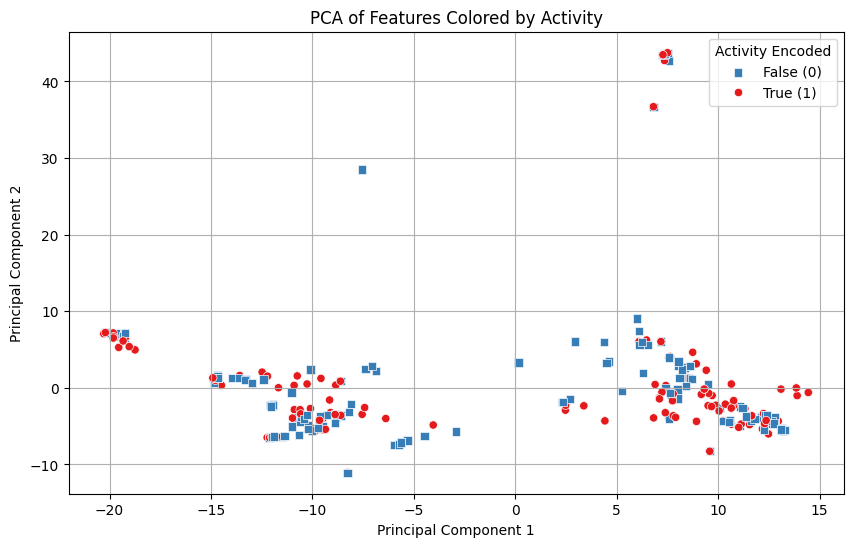

In [ ]:
# @title Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(norm_sm_desc_fps)

pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['activity_encoded'] = y.values

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='activity_encoded', palette='Set1', style='activity_encoded', markers=['o', 's'])
plt.title('PCA of Features Colored by Activity')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Activity Encoded', loc='best', labels=['False (0)', 'True (1)'])
plt.grid()
plt.show()

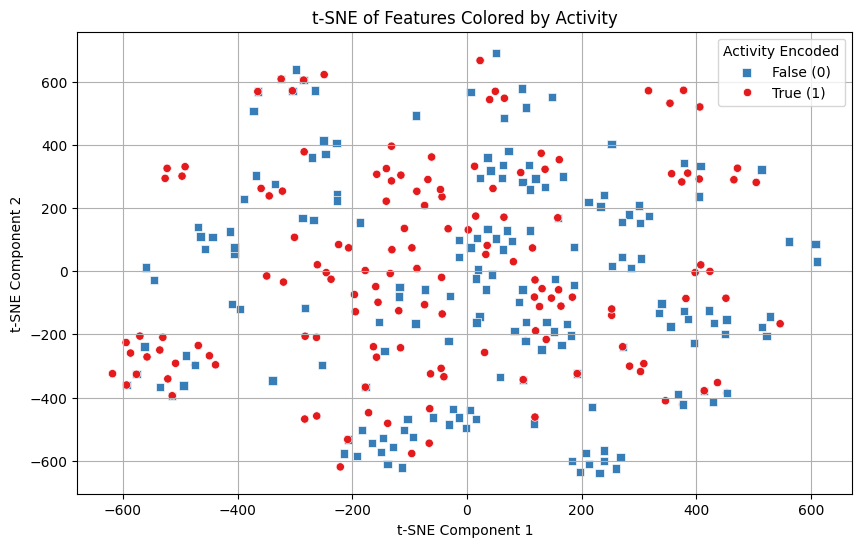

In [ ]:
# @title Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity = 30, n_iter = 3000)
X_tsne = tsne.fit_transform(norm_sm_desc_fps)

tsne_df = pd.DataFrame(data=X_tsne, columns=['t-SNE1', 't-SNE2'])
tsne_df['activity_encoded'] = y.values

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='activity_encoded', palette='Set1', style='activity_encoded', markers=['o', 's'])
plt.title('t-SNE of Features Colored by Activity')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Activity Encoded', loc='best', labels=['False (0)', 'True (1)'])
plt.grid()
plt.show()

In [ ]:
# @title 3D t-SNE
tsne = TSNE(n_components=3, random_state=42, perplexity = 30, n_iter = 5000)
X_tsne = tsne.fit_transform(norm_sm_desc_fps)

tsne_df = pd.DataFrame(data=X_tsne, columns=['t-SNE1', 't-SNE2', 't-SNE3'])
tsne_df['activity_encoded'] = y.values

import plotly.express as px
fig = px.scatter_3d(tsne_df, x='t-SNE1', y='t-SNE2', z='t-SNE3',
                    color='activity_encoded',
                    labels={'activity_encoded': 'Activity'},
                    title='3D t-SNE of Features Colored by Activity',
                    color_continuous_scale=px.colors.sequential.Viridis)

fig.update_layout(
    scene=dict(
        xaxis_title='t-SNE1',
        yaxis_title='t-SNE2',
        zaxis_title='t-SNE3',
    ),
    width=1000,
    height=800,
)

fig.show()

In [ ]:
print("Shape of smile embedding: ", norm_sm_desc_fps.shape)

Shape of smile embedding:  (396, 2086)


In [ ]:
X_smiles = norm_sm_desc_fps

Loading POI Embedding

In [ ]:
!ls {train_dir}

 scaffold_protbert_E3_train_embeddings.npy   scaffold_train_e3_descriptors.csv
 scaffold_protbert_train_embeddings1.npy     scaffold_train_fingerprints.csv
 scaffold_protbert_train_embeddings.npy      scaffold_train_protein_descriptors.csv
 scaffold_train_data.csv		    'Untitled folder'
 scaffold_train_descriptors.csv


In [ ]:
poi_embeddings = np.load(os.path.join(train_dir, 'scaffold_protbert_train_embeddings.npy'))

print("Shape of the POI embeddings:", poi_embeddings.shape)
print("Embeddings data:\n", poi_embeddings)

Shape of the POI embeddings: (396, 1, 1024)
Embeddings data:
 [[[ 0.13386941  0.05353465  0.06886485 ... -0.09261771 -0.01357365
   -0.00138825]]

 [[ 0.11961078  0.05782531  0.08993027 ... -0.10497797 -0.0319482
   -0.00608625]]

 [[ 0.08261685  0.03501701  0.09916995 ... -0.04250302 -0.04590534
    0.02188756]]

 ...

 [[ 0.13350876  0.07600185  0.10003502 ... -0.09753988 -0.01873155
    0.01210992]]

 [[ 0.1360468   0.02717672  0.08883537 ... -0.07814874 -0.02493447
    0.01673523]]

 [[ 0.13930644  0.02191801  0.10039955 ... -0.06770063 -0.04786647
    0.04304701]]]


In [ ]:
type(poi_embeddings)

numpy.ndarray

In [ ]:
X_poi = poi_embeddings

Visualizing POI Embeddings

In [ ]:
# Embeddings are in shape (1122, 1, 1024)
reshaped_poi_embeddings = poi_embeddings.squeeze()  # Remove singleton dimensions
print("Shape of reshaped POI embeddings:", reshaped_poi_embeddings.shape)

Shape of reshaped POI embeddings: (396, 1024)


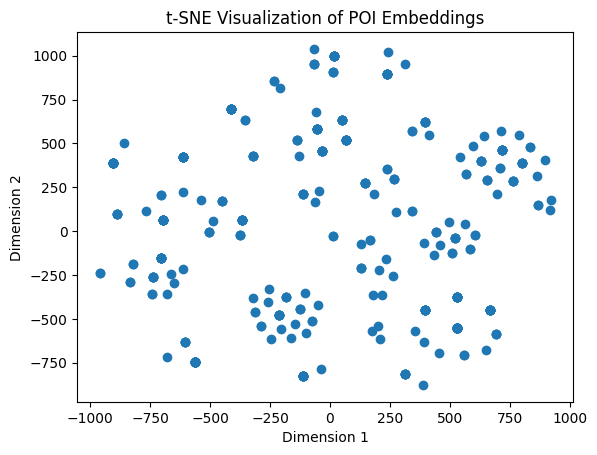

In [ ]:
tsne = TSNE(n_components=2, random_state=0, perplexity = 30, n_iter = 3000)
embeddings_2d = tsne.fit_transform(reshaped_poi_embeddings)

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('t-SNE Visualization of POI Embeddings')
plt.show()

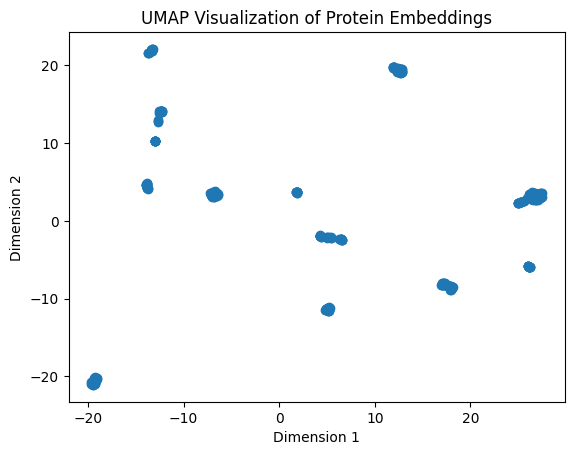

In [ ]:
import umap
import matplotlib.pyplot as plt

umap_model = umap.UMAP(n_components=2, random_state=0)
embeddings_2d = umap_model.fit_transform(reshaped_poi_embeddings)

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('UMAP Visualization of Protein Embeddings')
plt.show()

In [ ]:
protein_names = df['Uniprot'].values

In [ ]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder

umap_model = umap.UMAP(n_components=2, random_state=0)
reduced_embeddings = umap_model.fit_transform(reshaped_poi_embeddings)

vis_df = pd.DataFrame(reduced_embeddings, columns=['UMAP1', 'UMAP2'])
vis_df['protein_name'] = protein_names

label_encoder = LabelEncoder()
vis_df['protein_name_encoded'] = label_encoder.fit_transform(vis_df['protein_name'])

fig = px.scatter(
    vis_df,
    x='UMAP1',
    y='UMAP2',
    color='protein_name',
    title='Protein Sequence Embeddings Visualization with UMAP',
    labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
    color_discrete_sequence=px.colors.qualitative.Dark24
)

fig.show()

Loading E3 ligase embedding

In [ ]:
E3_embeddings = np.load(os.path.join(train_dir, 'scaffold_protbert_E3_train_embeddings.npy'))

print("Shape of the E3 embeddings:", E3_embeddings.shape)
print("Embeddings data:\n", E3_embeddings)

Shape of the E3 embeddings: (396, 1024)
Embeddings data:
 [[0.43424756 0.18499469 0.39883067 ... 0.83152859 0.42541658 0.53080337]
 [0.19045388 0.38409453 0.42333567 ... 0.09469049 0.44261657 0.64497978]
 [0.39493565 0.47171369 0.03883273 ... 0.17940007 0.70929028 0.32863597]
 ...
 [0.36174416 0.48063883 0.04868177 ... 0.74979375 0.2717859  0.83191802]
 [0.37324302 0.94961461 0.77006818 ... 0.90595341 0.33031826 0.03945031]
 [0.5578509  0.93223722 0.15832601 ... 0.41229089 0.94985685 0.04741276]]


In [ ]:
X_e3 = E3_embeddings

Visualizing E3 Ligase Embeddings

In [ ]:
df.columns

Index(['Uniprot', 'Smiles', 'E3 Ligase', 'Cell Type', 'POI Sequence',
       'E3 Ligase Uniprot', 'E3 Ligase Sequence', 'Activity',
       'activity_encoded'],
      dtype='object')

In [ ]:
protein_names = df['E3 Ligase'].values

In [ ]:
reshaped_E3_embeddings = E3_embeddings.squeeze()
print("Shape of reshaped E3 embeddings:", reshaped_E3_embeddings.shape)

Shape of reshaped E3 embeddings: (396, 1024)


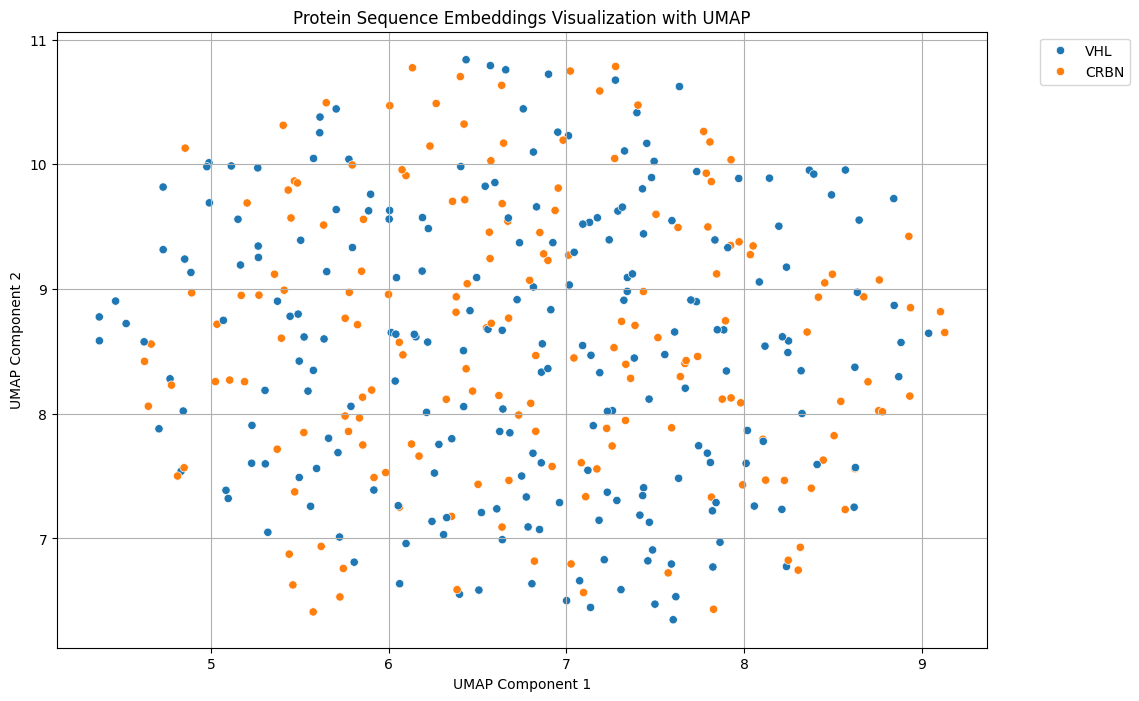

In [ ]:
umap_model = umap.UMAP(n_components=2, random_state=42)
reduced_embeddings = umap_model.fit_transform(reshaped_E3_embeddings)

vis_df = pd.DataFrame(reduced_embeddings, columns=['UMAP1', 'UMAP2'])
vis_df['protein_name'] = protein_names

label_encoder = LabelEncoder()
vis_df['protein_name_encoded'] = label_encoder.fit_transform(vis_df['protein_name'])

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='protein_name', palette='tab10', data=vis_df, legend='full')
plt.title('Protein Sequence Embeddings Visualization with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
print("shape of Label column:", y.shape)

shape of Label column: (396,)


In [ ]:
print("Value counts of label column are: ",y.value_counts())

Value counts of label column are:  activity_encoded
1    220
0    176
Name: count, dtype: int64


LOADING VALIDATION DATA

In [ ]:
# val_dir = os.path.join(data_dir, 'val')

In [ ]:
!ls {val_dir}

 scaffold_protbert_E3_val_embeddings.npy   scaffold_val_e3_descriptors.csv
 scaffold_protbert_val_embeddings1.npy	   scaffold_val_fingerprints.csv
 scaffold_protbert_val_embeddings.npy	   scaffold_val_protein_descriptors.csv
 scaffold_val_data.csv			  'Untitled folder'
 scaffold_val_descriptors.csv


In [ ]:
df_val = pd.read_csv(os.path.join(val_dir, 'scaffold_val_data.csv'))

In [ ]:
df_val

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity
0,O60885,Cc1nnc2n1-c1ccc(-c3cnn(CCCCCCCN4CCC(c5cccc6c5C...,CRBN,HEK293T,MSAESGPGTRLRNLPVMGDGLETSQMSTTQAQAQPQPANAASTNPP...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True
1,Q9UM73,CCc1cc2c(cc1N1CCC(N3CCN(CCCC#Cc4cccc5c4CN(C4CC...,CRBN,SR,MGAIGLLWLLPLLLSTAAVGSGMGTGQRAGSPAAGPPLQPREPLSY...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
2,P10275,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,LNCaP,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False
3,Q05397,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,PC3,MAAAYLDPNLNHTPNSSTKTHLGTGMERSPGAMERVLKVFHYFESN...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
4,Q15059,CC(=O)N1c2ccc(-c3ccc(C(=O)NCCOCCOCC(=O)N[C@H](...,VHL,HeLa,MSTATTVAPAGIPATPGPVNPPPPEVSNPSKPGRKTNQLQYMQNVV...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False
...,...,...,...,...,...,...,...,...
72,Q9UBN7,CCCCN(Cc1ccc(C(=O)NO)cc1)C(=O)Nc1ccc(OCCCCCCCC...,VHL,MM1S,MTSTGQDSTTTRQRRSRQNPQSPPQDSSVTSKRNIKKGAVPRSIPN...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
73,Q06187,O=C1CCC(N2C(=O)c3cccc(NCCOCCOCCOCCOCCOCCNC(=O)...,CRBN,JeKo-1,MAAVILESIFLKRSQQKKKTSPLNFKKRLFLLTVHKLSYYEYDFER...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True
74,Q06187,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@@H]2C...,CRBN,THP-1,MAAVILESIFLKRSQQKKKTSPLNFKKRLFLLTVHKLSYYEYDFER...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
75,Q96SW2,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,HEK293T,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False


In [ ]:
# @title Encode the 'activity' column

df_val['activity_encoded'] = df_val['Activity'].astype(int)
df_val.head()

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity,activity_encoded
0,O60885,Cc1nnc2n1-c1ccc(-c3cnn(CCCCCCCN4CCC(c5cccc6c5C...,CRBN,HEK293T,MSAESGPGTRLRNLPVMGDGLETSQMSTTQAQAQPQPANAASTNPP...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True,1
1,Q9UM73,CCc1cc2c(cc1N1CCC(N3CCN(CCCC#Cc4cccc5c4CN(C4CC...,CRBN,SR,MGAIGLLWLLPLLLSTAAVGSGMGTGQRAGSPAAGPPLQPREPLSY...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False,0
2,P10275,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,LNCaP,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False,0
3,Q05397,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,PC3,MAAAYLDPNLNHTPNSSTKTHLGTGMERSPGAMERVLKVFHYFESN...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,1
4,Q15059,CC(=O)N1c2ccc(-c3ccc(C(=O)NCCOCCOCC(=O)N[C@H](...,VHL,HeLa,MSTATTVAPAGIPATPGPVNPPPPEVSNPSKPGRKTNQLQYMQNVV...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False,0


Loading Descriptors and Fingerprints

In [ ]:
val_sm_desc = pd.read_csv(os.path.join(val_dir, 'scaffold_val_descriptors.csv'))
val_sm_desc.shape

(77, 39)

In [ ]:
val_sm_fps = pd.read_csv(os.path.join(val_dir, 'scaffold_val_fingerprints.csv'))
val_sm_fps.shape

(77, 2048)

In [ ]:
val_sm_desc_fps = pd.concat([val_sm_desc, val_sm_fps], axis=1)
val_sm_desc_fps.shape

(77, 2087)

In [ ]:
val_sm_desc_fps = val_sm_desc_fps.drop(columns=['SPS'])
val_sm_desc_fps.shape

(77, 2086)

In [ ]:
print("Shape of Validation smile embedding: ",val_sm_desc_fps.shape)

Shape of Validation smile embedding:  (77, 2086)


In [ ]:
# @title Normalizing
loaded_scaler = joblib.load('/content/drive/MyDrive/mtech_project/scaffold_scaler.pkl')

val_scaled = loaded_scaler.transform(val_sm_desc_fps)

In [ ]:
val_scaled

array([[-0.19898407,  1.56404692, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       [-0.08526649, -0.11900357,  1.06083028, ..., -0.29143011,
        -0.33520076,  0.        ],
       [ 0.36607953, -1.24103723, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       ...,
       [ 0.4176635 , -0.6800204 , -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       [-0.86041886, -1.24103723, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       [ 1.52622171, -1.24103723, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ]])

In [ ]:
val_y = df_val['activity_encoded']

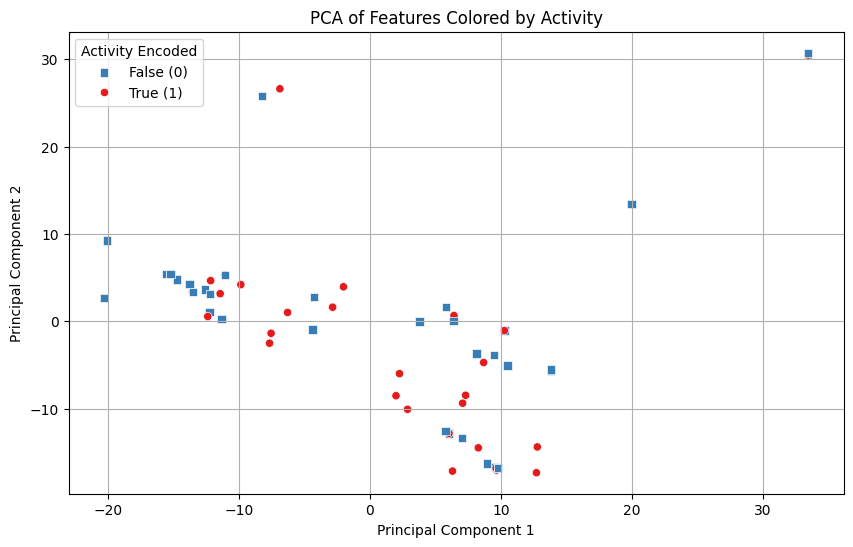

In [ ]:
# @title Apply PCA
pca = PCA(n_components=2)
val_pca = pca.fit_transform(val_scaled)

val_pca_df = pd.DataFrame(data=val_pca, columns=['PCA1', 'PCA2'])
val_pca_df['activity_encoded'] = val_y.values

plt.figure(figsize=(10, 6))
sns.scatterplot(data=val_pca_df, x='PCA1', y='PCA2', hue='activity_encoded', palette='Set1', style='activity_encoded', markers=['o', 's'])
plt.title('PCA of Features Colored by Activity')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Activity Encoded', loc='best', labels=['False (0)', 'True (1)'])
plt.grid()
plt.show()

In [ ]:
# @title Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
val_tsne = tsne.fit_transform(val_scaled)

val_tsne_df = pd.DataFrame(data=val_tsne, columns=['t-SNE1', 't-SNE2'])
val_tsne_df['activity_encoded'] = val_y.values

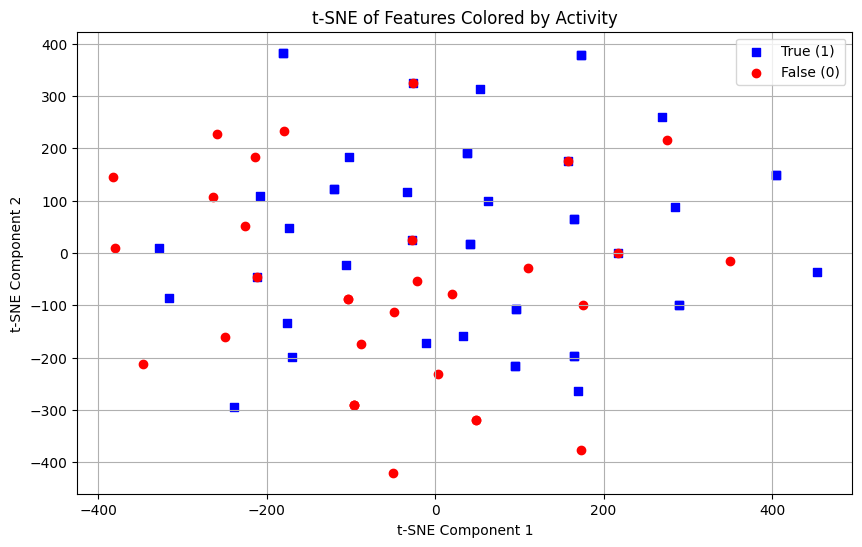

In [ ]:
plt.figure(figsize=(10, 6))

for activity in val_tsne_df['activity_encoded'].unique():
    subset = val_tsne_df[val_tsne_df['activity_encoded'] == activity]
    if activity == 0:
        plt.scatter(subset['t-SNE1'], subset['t-SNE2'],   # Changed column names to 't-SNE1' and 't-SNE2'
                    color='red', marker='o', label='False (0)')
    else:
        plt.scatter(subset['t-SNE1'], subset['t-SNE2'],   # Changed column names to 't-SNE1' and 't-SNE2'
                    color='blue', marker='s', label='True (1)')

plt.title('t-SNE of Features Colored by Activity')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid()
plt.show()

In [ ]:
!ls {val_dir}

 scaffold_protbert_E3_val_embeddings.npy   scaffold_val_e3_descriptors.csv
 scaffold_protbert_val_embeddings1.npy	   scaffold_val_fingerprints.csv
 scaffold_protbert_val_embeddings.npy	   scaffold_val_protein_descriptors.csv
 scaffold_val_data.csv			  'Untitled folder'
 scaffold_val_descriptors.csv


Loading Validation POI Embeddings

In [ ]:
val_poi_embeddings = np.load(os.path.join(val_dir, 'scaffold_protbert_val_embeddings.npy'))

print("Shape of the Validation POI embeddings:", val_poi_embeddings.shape)
print("Embeddings data:\n", val_poi_embeddings)

Shape of the Validation POI embeddings: (77, 1, 1024)
Embeddings data:
 [[[ 0.1360468   0.02717672  0.08883537 ... -0.07814874 -0.02493447
    0.01673523]]

 [[ 0.106759    0.12840816  0.08193652 ... -0.05629858  0.02347046
   -0.05023517]]

 [[ 0.13386941  0.05353465  0.06886485 ... -0.09261771 -0.01357365
   -0.00138825]]

 ...

 [[ 0.1341203   0.07427345  0.08591197 ... -0.10232301 -0.01976055
   -0.0050316 ]]

 [[-0.04554563  0.03944064  0.06054722 ... -0.02079228 -0.00297423
    0.0248237 ]]

 [[ 0.11187976  0.02072983  0.0913576  ... -0.0580162  -0.05010705
    0.03584022]]]


Loading Validation E3 Embeddings

In [ ]:
val_E3_embeddings = np.load(os.path.join(val_dir, 'scaffold_protbert_E3_val_embeddings.npy'))

print("Shape of the Validation E3 embeddings:", val_E3_embeddings.shape)
print("Embeddings data:\n", val_E3_embeddings)

Shape of the Validation E3 embeddings: (77, 1024)
Embeddings data:
 [[0.94384847 0.82384932 0.60714378 ... 0.72790216 0.2300433  0.78765285]
 [0.89221553 0.79898879 0.03864018 ... 0.74494464 0.75305462 0.79029886]
 [0.08680419 0.50730957 0.01096523 ... 0.37234744 0.93140564 0.1226383 ]
 ...
 [0.0720497  0.08378932 0.27058075 ... 0.14180511 0.63578785 0.82772843]
 [0.21749482 0.3002935  0.75911669 ... 0.91329444 0.84866151 0.82900087]
 [0.27226709 0.92407548 0.10982382 ... 0.67149103 0.84625943 0.84860722]]


LOADING TEST DATA

In [ ]:
!ls {test_dir}

 scaffold_protbert_E3_test_embeddings.npy   scaffold_test_e3_descriptors.csv
 scaffold_protbert_test_embeddings1.npy     scaffold_test_fingerprints.csv
 scaffold_protbert_test_embeddings.npy	    scaffold_test_protein_descriptors.csv
 scaffold_test_data.csv			   'Untitled folder'
 scaffold_test_descriptors.csv


In [ ]:
test_df = pd.read_csv("/content/drive/MyDrive/mtech_project/data/test/scaffold_test_data.csv")
test_df

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity
0,Q92830,CN1CC(Nc2cnn(C)c(=O)c2Br)CC(c2ccc(C(=O)N(C)CCC...,CRBN,THP1,MAEPSQAPTPAPAAQPRPLQSPAPAPTPTPAPSPASAPIPTPTPAP...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True
1,P10275,N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CC5C...,CRBN,VCaP,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True
2,P15056,CCCS(=O)(=O)Nc1ccc(F)c(-n2cc(-c3cncnc3)c3nc(N(...,CRBN,A375,MAALSGGGGGGAEPGQALFNGDMEPEAGAGAGAAASSAADPAIPEE...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
3,P10275,N#Cc1ccc(OC2CCN(C(=O)c3ccc(N4CCC(N5CCN(c6ccc7c...,CRBN,VCaP,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
4,Q9NWZ3,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]...,CRBN,HEK293T,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
5,P15056,Nc1nccc(-c2sc(C3CCN(C(=O)CCOCCOCCOCCNc4cccc5c4...,CRBN,A375,MAALSGGGGGGAEPGQALFNGDMEPEAGAGAGAAASSAADPAIPEE...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
6,Q9NWZ3,O=C1CCC(N2C(=O)c3ccc(OC4CCC(CN5CCN(Cc6ccc7nc(N...,CRBN,MCF7,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False
7,Q9UHD2,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,Panc02.13,MQSTSNHLWLLSDILGQGATANVFRGRHKKTGDLFAIKVFNNISFL...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False
8,O60885,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,PC3-S1,MSAESGPGTRLRNLPVMGDGLETSQMSTTQAQAQPQPANAASTNPP...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
9,O60885,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,PC3-S1,MSAESGPGTRLRNLPVMGDGLETSQMSTTQAQAQPQPANAASTNPP...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True


In [ ]:
test_df['activity_encoded'] = test_df['Activity'].astype(int)
test_df.head()

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity,activity_encoded
0,Q92830,CN1CC(Nc2cnn(C)c(=O)c2Br)CC(c2ccc(C(=O)N(C)CCC...,CRBN,THP1,MAEPSQAPTPAPAAQPRPLQSPAPAPTPTPAPSPASAPIPTPTPAP...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True,1
1,P10275,N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CC5C...,CRBN,VCaP,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True,1
2,P15056,CCCS(=O)(=O)Nc1ccc(F)c(-n2cc(-c3cncnc3)c3nc(N(...,CRBN,A375,MAALSGGGGGGAEPGQALFNGDMEPEAGAGAGAAASSAADPAIPEE...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False,0
3,P10275,N#Cc1ccc(OC2CCN(C(=O)c3ccc(N4CCC(N5CCN(c6ccc7c...,CRBN,VCaP,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False,0
4,Q9NWZ3,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]...,CRBN,HEK293T,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False,0


In [ ]:
y_test = test_df['activity_encoded']

In [ ]:
y_test = np.array(y_test)
y_test.shape

(31,)

In [ ]:
test_desc = pd.read_csv("/content/drive/MyDrive/mtech_project/data/test/scaffold_test_descriptors.csv")
test_desc.shape

(31, 39)

In [ ]:
test_fing = pd.read_csv("/content/drive/MyDrive/mtech_project/data/test/scaffold_test_fingerprints.csv")
test_fing.shape

(31, 2048)

In [ ]:
# concatenate test_desc and test_fing
test_sm_fin = pd.concat([test_desc, test_fing], axis=1)
test_sm_fin.shape

(31, 2087)

In [ ]:
test_sm_fin = test_sm_fin.drop(columns=['SPS'])

In [ ]:
test_sm_fin.shape

(31, 2086)

In [ ]:
ls

'=1.26.0'                        embeddings/               Protac_final_database.csv
 1_Preprocessing_file.ipynb      Filtered_crbnnvhl.ipynb   Random_forest.ipynb
 2_train_test_split.ipynb        filtered_protac_cnv.csv   Required_data.csv
 3.1_scaffold_embeddings.ipynb   final_df.csv              scaffold_scaler.pkl
 3.2_Cluster_embeddings.ipynb    Fingerprints.ipynb        src/
 checkpoints/                    outputs/                  Untitled1.ipynb
 data/                           protac_cnv.csv


In [ ]:
# @title Test Smile dataset ready

loaded_scaler = joblib.load('scaffold_scaler.pkl')

scaled_new_data = loaded_scaler.transform(test_sm_fin)
scaled_new_data

array([[-1.34724011,  0.44201326, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       [-0.71740186, -0.11900357,  1.06083028, ..., -0.29143011,
        -0.33520076,  0.        ],
       [-0.19898407,  1.00303009, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       ...,
       [ 3.20636325, -1.24103723, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       [ 1.02981144,  1.00303009, -0.68227673, ..., -0.29143011,
        -0.33520076,  0.        ],
       [-1.314062  ,  0.44201326,  1.06083028, ..., -0.29143011,
        -0.33520076,  0.        ]])

In [ ]:
# @title Test POI SEquence embedding

test_poi = np.load('/content/drive/MyDrive/mtech_project/data/test/scaffold_protbert_test_embeddings.npy')

print("Shape of loaded data:", test_poi.shape)
print("Contents of loaded data:\n", test_poi)

Shape of loaded data: (31, 1, 1024)
Contents of loaded data:
 [[[ 0.13222764  0.06053789  0.08701084 ... -0.10989261 -0.02998055
   -0.01264389]]

 [[ 0.13386941  0.05353465  0.06886485 ... -0.09261771 -0.01357365
   -0.00138825]]

 [[ 0.1312182   0.07465646  0.09058126 ... -0.11004335 -0.03612534
   -0.01500606]]

 ...

 [[ 0.1189507   0.05142632  0.06081518 ... -0.11223452 -0.02315804
   -0.00506759]]

 [[ 0.1312182   0.07465646  0.09058126 ... -0.11004335 -0.03612534
   -0.01500606]]

 [[ 0.13386941  0.05353465  0.06886485 ... -0.09261771 -0.01357365
   -0.00138825]]]


In [ ]:
# @title Test E3 LIGASE embeddings

test_e3 = np.load("/content/drive/MyDrive/mtech_project/data/test/scaffold_protbert_E3_test_embeddings.npy")

print("Shape of loaded data:", test_e3.shape)
print("Contents of loaded data:\n", test_e3)

Shape of loaded data: (31, 1024)
Contents of loaded data:
 [[0.13884882 0.4367849  0.69867186 ... 0.84748686 0.31091413 0.47971027]
 [0.52640798 0.59406789 0.40068838 ... 0.64418911 0.53093575 0.37699656]
 [0.85008204 0.39337425 0.79144497 ... 0.44169387 0.59779337 0.84750311]
 ...
 [0.46596203 0.76432802 0.29329437 ... 0.12944531 0.67118799 0.68518345]
 [0.08073244 0.85503428 0.63390283 ... 0.57615939 0.7187336  0.73795517]
 [0.07643778 0.70866035 0.31278041 ... 0.04167669 0.97028887 0.65743398]]


MODEL BUILDING


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Add, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
X_train_smiles = norm_sm_desc_fps
X_train_poi = poi_embeddings
X_train_e3 = E3_embeddings
y_train = y

X_val_smiles = val_scaled
X_val_poi = val_poi_embeddings
X_val_e3 = val_E3_embeddings
y_val = val_y

In [ ]:

X_train_smiles.shape, X_train_poi.shape, X_train_e3.shape, y_train.shape

((396, 2086), (396, 1, 1024), (396, 1024), (396,))

In [ ]:
# @title MODEL-1

# Define input layers
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Add, Concatenate, Dropout
from tensorflow.keras.layers import Lambda



smile_input = Input(shape=(2086,), name='smile_input')
poi_input = Input(shape=(1024, ), name='poi_input')
e3_input = Input(shape=(1024, ), name='e3_input')

# Expand dimensions for CNN
smile_x = Lambda(lambda x: tf.expand_dims(x, axis=-1))(smile_input)

# Apply Conv1D and MaxPooling
smile_x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(smile_x)
smile_x = MaxPooling1D(pool_size=2)(smile_x)
smile_x = Flatten()(smile_x)



# LSTM for POI embeddings
#poi_x = LSTM(1024, return_sequences=True)(poi_input)
#poi_x = LSTM(1024)(poi_x)

poi_x = Lambda(lambda x: tf.expand_dims(x, axis=1))(poi_input)
poi_x = LSTM(1024, return_sequences=True)(poi_x)
poi_x = LSTM(1024)(poi_x)

# LSTM for E3 embeddings
#e3_x = LSTM(1024, return_sequences=True)(e3_input)
#e3_x = LSTM(1024)(e3_x)

e3_x = Lambda(lambda x: tf.expand_dims(x, axis=1))(e3_input)
e3_x = LSTM(1024, return_sequences=True)(e3_x)
e3_x = LSTM(1024)(e3_x)

# Residual connections
poi_residual = Add()([poi_input, poi_x])
e3_residual = Add()([e3_input, e3_x])

poi_residual = Flatten()(poi_residual)
e3_residual = Flatten()(e3_residual)

# Concatenate all features
concatenated = Concatenate()([smile_x, poi_residual, e3_residual])

# Fully connected layers
x = Dense(128, activation='relu')(concatenated)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# Create model
model = Model(inputs=[smile_input, poi_input, e3_input], outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

# Fit the model
history = model.fit([X_smiles, X_poi, X_e3], y, epochs=30, batch_size=32, validation_split=0.2)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ poi_input (InputLayer)    │ (None, 1024)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ e3_input (InputLayer)     │ (None, 1024)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ smile_input (InputLayer)  │ (None, 2086)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_5 (Lambda)         │ (None, 1, 1024)        │              0 │ poi_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_6 (Lambda)         │ (None, 1, 1024)        │              0 │ e3_input[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_4 (Lambda)         │ (None, 2086, 1)        │              0 │ smile_input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_5 (LSTM)             │ (None, 1, 1024)        │      8,392,704 │ lambda_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_7 (LSTM)             │ (None, 1, 1024)        │      8,392,704 │ lambda_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 2086, 64)       │            256 │ lambda_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_6 (LSTM)             │ (None, 1024)           │      8,392,704 │ lstm_5[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_8 (LSTM)             │ (None, 1024)           │      8,392,704 │ lstm_7[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_2           │ (None, 1043, 64)       │              0 │ conv1d_4[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 1024)           │              0 │ poi_input[0][0],       │
│                           │                        │                │ lstm_6[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 1024)           │              0 │ e3_input[0][0],        │
│                           │                        │                │ lstm_8[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_4 (Flatten)       │ (None, 66752)          │              0 │ max_pooling1d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)       │ (None, 1024)           │              0 │ add_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_6 (Flatten)       │ (None, 1024)           │              0 │ add_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 68800)          │              0 │ flatten_4[0][0],       │
│ (Concatenate)        

 Total params: 42,385,921 (161.69 MB)

 Trainable params: 42,385,921 (161.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


ValueError: Input 1 of layer "functional_1" is incompatible with the layer: expected shape=(None, 1024), found shape=(None, 1, 1024)

In [ ]:
# MODEL-1 (Updated and Corrected)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Flatten, Dense,
    LSTM, Add, Concatenate, Dropout, Lambda
)
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np

# Define input layers
smile_input = Input(shape=(2086,), name='smile_input')          # Shape: (batch_size, 2086)
poi_input = Input(shape=(1024,), name='poi_input')              # Shape: (batch_size, 1024)
e3_input = Input(shape=(1024,), name='e3_input')                # Shape: (batch_size, 1024)

# CNN for SMILES embeddings
smile_x = Lambda(lambda x: tf.expand_dims(x, axis=-1))(smile_input)  # Shape: (batch_size, 2086, 1)
smile_x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(smile_x)
smile_x = MaxPooling1D(pool_size=2)(smile_x)
smile_x = Flatten()(smile_x)

# LSTM for POI embeddings
poi_x = Lambda(lambda x: tf.expand_dims(x, axis=1))(poi_input)       # Shape: (batch_size, 1, 1024)
poi_x = LSTM(1024, return_sequences=True)(poi_x)
poi_x = LSTM(1024)(poi_x)

# LSTM for E3 embeddings
e3_x = Lambda(lambda x: tf.expand_dims(x, axis=1))(e3_input)         # Shape: (batch_size, 1, 1024)
e3_x = LSTM(1024, return_sequences=True)(e3_x)
e3_x = LSTM(1024)(e3_x)

# Residual connections (optional, but flattened input must match)
poi_residual = Add()([poi_input, poi_x])
e3_residual = Add()([e3_input, e3_x])

# Concatenate all features
concatenated = Concatenate()([
    smile_x,
    poi_residual,
    e3_residual
])

# Fully connected layers
x = Dense(128, activation='relu')(concatenated)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# Create and compile model
model = Model(inputs=[smile_input, poi_input, e3_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Summary
model.summary()

# ========== Example training ==========

# Assuming your data is loaded as:
# X_smiles -> shape (num_samples, 2086)
# X_poi    -> shape (num_samples, 1024) or (num_samples, 1, 1024)
# X_e3     -> shape (num_samples, 1024) or (num_samples, 1, 1024)
# y        -> shape (num_samples,) or (num_samples, 1)

# Ensure proper shapes (reshape if needed)
X_poi = np.array(X_poi).reshape((-1, 1024))
X_e3 = np.array(X_e3).reshape((-1, 1024))
X_smiles = np.array(X_smiles).reshape((-1, 2086))
y = np.array(y).reshape((-1, 1))

# Train the model
history = model.fit(
    [X_smiles, X_poi, X_e3],
    y,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ smile_input (InputLayer)  │ (None, 2086)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ poi_input (InputLayer)    │ (None, 1024)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ e3_input (InputLayer)     │ (None, 1024)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_7 (Lambda)         │ (None, 2086, 1)        │              0 │ smile_input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_8 (Lambda)         │ (None, 1, 1024)        │              0 │ poi_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_9 (Lambda)         │ (None, 1, 1024)        │              0 │ e3_input[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_5 (Conv1D)         │ (None, 2086, 64)       │            256 │ lambda_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_9 (LSTM)             │ (None, 1, 1024)        │      8,392,704 │ lambda_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_11 (LSTM)            │ (None, 1, 1024)        │      8,392,704 │ lambda_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_3           │ (None, 1043, 64)       │              0 │ conv1d_5[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_10 (LSTM)            │ (None, 1024)           │      8,392,704 │ lstm_9[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_12 (LSTM)            │ (None, 1024)           │      8,392,704 │ lstm_11[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_7 (Flatten)       │ (None, 66752)          │              0 │ max_pooling1d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 1024)           │              0 │ poi_input[0][0],       │
│                           │                        │                │ lstm_10[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_5 (Add)               │ (None, 1024)           │              0 │ e3_input[0][0],        │
│                           │                        │                │ lstm_12[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 68800)          │              0 │ flatten_7[0][0],       │
│ (Concatenate)             │                        │                │ add_4[0][0],           │
│                           │                        │                │ add_5[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 128)            │      8,806,528 │ concatenate_2[0][0]    │
├──────────────────────

 Total params: 42,385,921 (161.69 MB)

 Trainable params: 42,385,921 (161.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5070 - loss: 1.5221 - val_accuracy: 0.7250 - val_loss: 0.6359
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 802ms/step - accuracy: 0.5677 - loss: 0.9810 - val_accuracy: 0.6875 - val_loss: 0.6119
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 959ms/step - accuracy: 0.6478 - loss: 0.6915 - val_accuracy: 0.7375 - val_loss: 0.6020
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 842ms/step - accuracy: 0.5990 - loss: 0.7187 - val_accuracy: 0.8000 - val_loss: 0.5431
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 777ms/step - accuracy: 0.6822 - loss: 0.5891 - val_accuracy: 0.8000 - val_loss: 0.5361
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 862ms/step - accuracy: 0.6502 - loss: 0.5824 - val_accuracy: 0.7750 - val_loss: 0.5236
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 956ms/step - accuracy: 0.7070 - loss: 0.4991 - val_accuracy: 0.7875 - val_loss: 0.5044
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 801ms/step - accuracy: 0.7215 - loss: 0.5017 - val_accuracy:

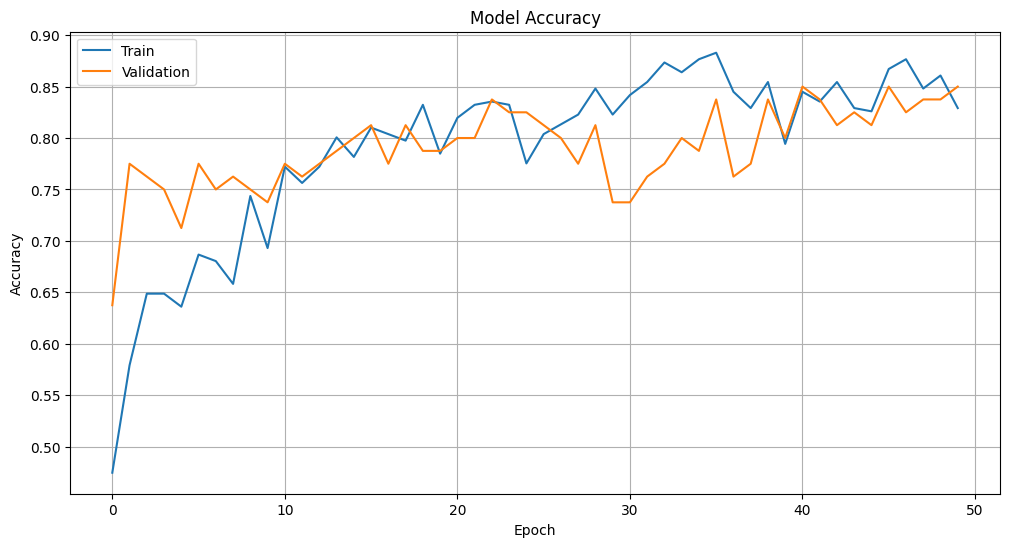

In [ ]:
 #@title Plot Train and Validation Curves

plt.figure(figsize=(12, 6))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
# MODEL-1 (Updated and Corrected)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Flatten, Dense,
    LSTM, Add, Concatenate, Dropout, Lambda
)
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np

# Define input layers
smile_input = Input(shape=(2086,), name='smile_input')          # Shape: (batch_size, 2086)
poi_input = Input(shape=(1024,), name='poi_input')              # Shape: (batch_size, 1024)
e3_input = Input(shape=(1024,), name='e3_input')                # Shape: (batch_size, 1024)

# CNN for SMILES embeddings
smile_x = Lambda(lambda x: tf.expand_dims(x, axis=-1))(smile_input)  # Shape: (batch_size, 2086, 1)
smile_x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(smile_x)
smile_x = MaxPooling1D(pool_size=2)(smile_x)
smile_x = Flatten()(smile_x)

# LSTM for POI embeddings
poi_x = Lambda(lambda x: tf.expand_dims(x, axis=1))(poi_input)       # Shape: (batch_size, 1, 1024)
poi_x = LSTM(1024, return_sequences=True)(poi_x)
poi_x = LSTM(1024)(poi_x)

# LSTM for E3 embeddings
e3_x = Lambda(lambda x: tf.expand_dims(x, axis=1))(e3_input)         # Shape: (batch_size, 1, 1024)
e3_x = LSTM(1024, return_sequences=True)(e3_x)
e3_x = LSTM(1024)(e3_x)

# Residual connections (optional, but flattened input must match)
poi_residual = Add()([poi_input, poi_x])
e3_residual = Add()([e3_input, e3_x])

# Concatenate all features
concatenated = Concatenate()([
    smile_x,
    poi_residual,
    e3_residual
])

# Fully connected layers
x = Dense(128, activation='relu')(concatenated)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# Create and compile model
model = Model(inputs=[smile_input, poi_input, e3_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Summary
model.summary()

# ========== Example training ==========

# Assuming your data is loaded as:
# X_smiles -> shape (num_samples, 2086)
# X_poi    -> shape (num_samples, 1024) or (num_samples, 1, 1024)
# X_e3     -> shape (num_samples, 1024) or (num_samples, 1, 1024)
# y        -> shape (num_samples,) or (num_samples, 1)

# Ensure proper shapes (reshape if needed)
X_poi = np.array(X_poi).reshape((-1, 1024))
X_e3 = np.array(X_e3).reshape((-1, 1024))
X_smiles = np.array(X_smiles).reshape((-1, 2086))
y = np.array(y).reshape((-1, 1))

# Train the model
history = model.fit(
    [X_smiles, X_poi, X_e3],
    y,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ smile_input (InputLayer)  │ (None, 2086)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ poi_input (InputLayer)    │ (None, 1024)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ e3_input (InputLayer)     │ (None, 1024)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_10 (Lambda)        │ (None, 2086, 1)        │              0 │ smile_input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_11 (Lambda)        │ (None, 1, 1024)        │              0 │ poi_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_12 (Lambda)        │ (None, 1, 1024)        │              0 │ e3_input[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_6 (Conv1D)         │ (None, 2086, 64)       │            256 │ lambda_10[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_13 (LSTM)            │ (None, 1, 1024)        │      8,392,704 │ lambda_11[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_15 (LSTM)            │ (None, 1, 1024)        │      8,392,704 │ lambda_12[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_4           │ (None, 1043, 64)       │              0 │ conv1d_6[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_14 (LSTM)            │ (None, 1024)           │      8,392,704 │ lstm_13[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_16 (LSTM)            │ (None, 1024)           │      8,392,704 │ lstm_15[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_8 (Flatten)       │ (None, 66752)          │              0 │ max_pooling1d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_6 (Add)               │ (None, 1024)           │              0 │ poi_input[0][0],       │
│                           │                        │                │ lstm_14[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_7 (Add)               │ (None, 1024)           │              0 │ e3_input[0][0],        │
│                           │                        │                │ lstm_16[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 68800)          │              0 │ flatten_8[0][0],       │
│ (Concatenate)             │                        │                │ add_6[0][0],           │
│                           │                        │                │ add_7[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 128)            │      8,806,528 │ concatenate_3[0][0]    │
├──────────────────────

 Total params: 42,385,921 (161.69 MB)

 Trainable params: 42,385,921 (161.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4645 - loss: 2.2611 - val_accuracy: 0.6375 - val_loss: 0.7228
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 868ms/step - accuracy: 0.5419 - loss: 1.3147 - val_accuracy: 0.7750 - val_loss: 0.5048
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 953ms/step - accuracy: 0.6795 - loss: 0.6943 - val_accuracy: 0.7625 - val_loss: 0.5484
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 798ms/step - accuracy: 0.6800 - loss: 0.5897 - val_accuracy: 0.7500 - val_loss: 0.5501
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 934ms/step - accuracy: 0.6470 - loss: 0.6838 - val_accuracy: 0.7125 - val_loss: 0.5057
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 958ms/step - accuracy: 0.6805 - loss: 0.5297 - val_accuracy: 0.7750 - val_loss: 0.4683
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 797ms/step - accuracy: 0.6477 - loss: 0.5649 - val_accuracy: 0.7500 - val_loss: 0.4962
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 959ms/step - accuracy: 0.6711 - loss: 0.5034 - val_accuracy: 

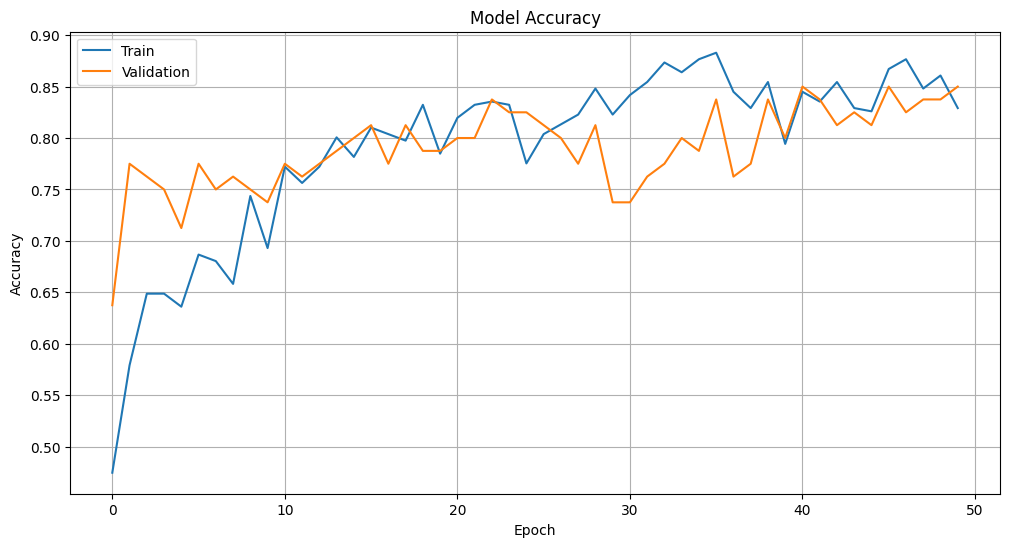

In [ ]:
# @title Plot Train and Validation Curves

plt.figure(figsize=(12, 6))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/mtech_project/Models/scaffold_model_1.h5')

# save in TensorFlow SavedModel format
model.save('/content/drive/MyDrive/mtech_project/Models/scaffold_model_1.keras')

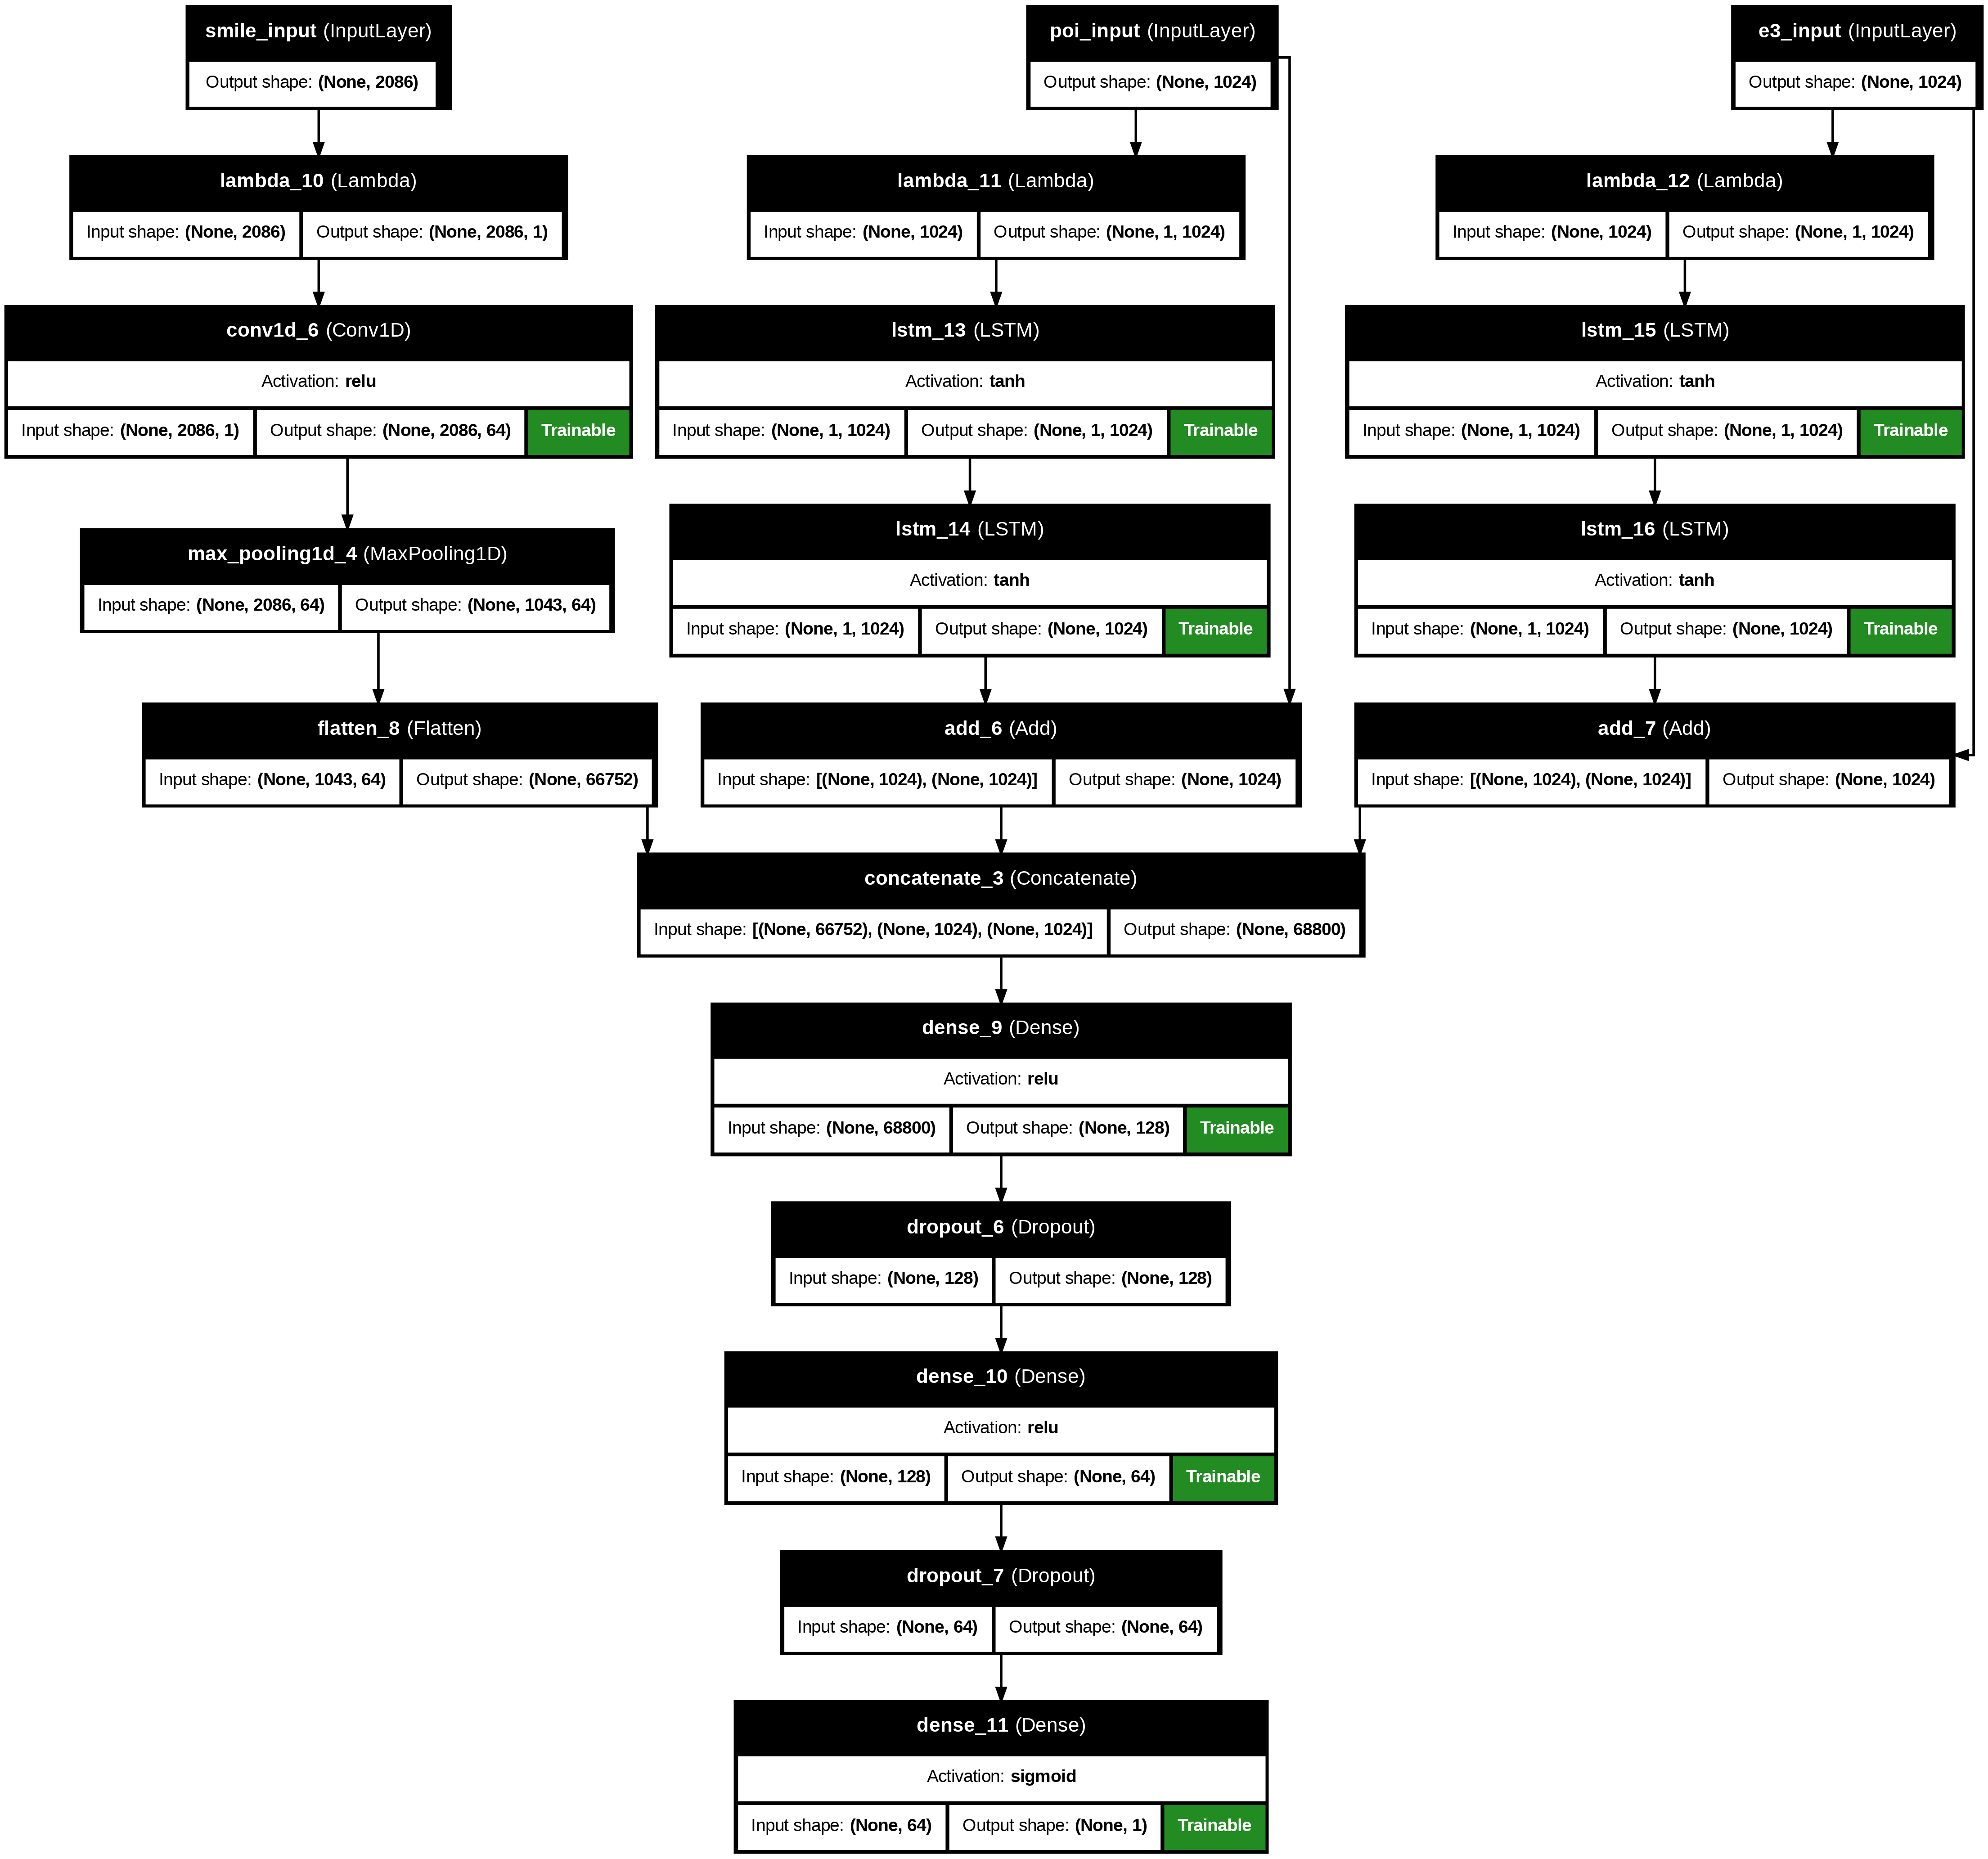

In [ ]:
# @title model visualization
# model = keras.models.load_model(model)

keras.utils.plot_model(
    model,
    to_file="model.png",
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=200,
    show_layer_activations=True,
    show_trainable=True,

)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step


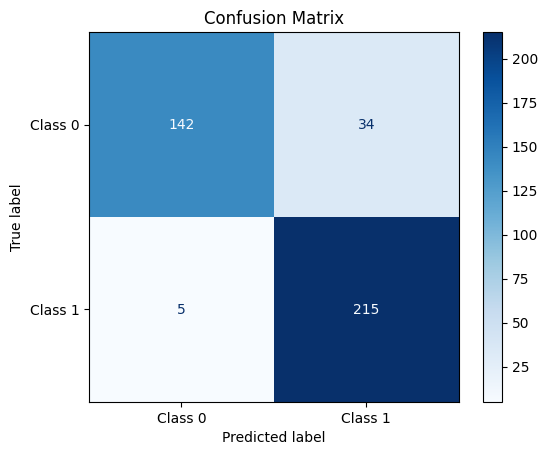

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities
y_pred_prob = model.predict([X_smiles, X_poi, X_e3])

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

# Generate confusion matrix
cm = confusion_matrix(y, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
Accuracy: 0.9015
Precision: 0.8635
Recall: 0.9773
F1 Score: 0.9168
ROC AUC: 0.9657
Log Loss: 0.2623


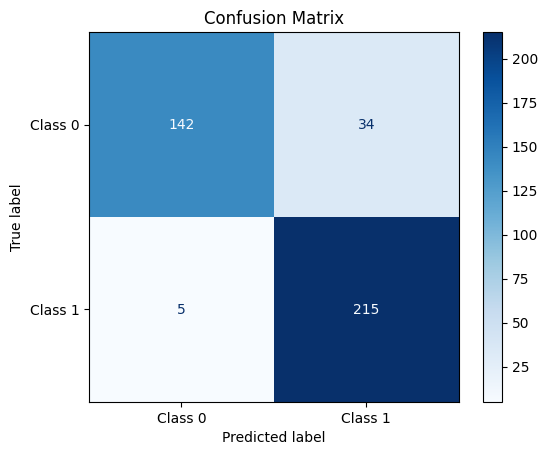

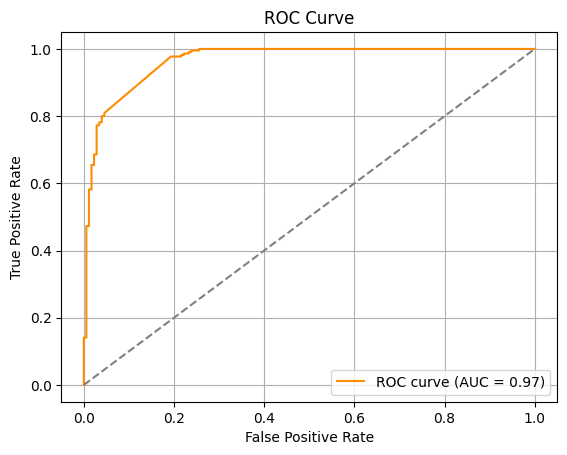

In [ ]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities and binary outputs
y_pred_prob = model.predict([X_smiles, X_poi, X_e3])
y_pred = (y_pred_prob > 0.5).astype(int)

# Convert y to array if not already
y_true = np.array(y)

# --- Metrics ---
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_prob)
logloss = log_loss(y_true, y_pred_prob)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Log Loss: {logloss:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# MODEL-1 (Updated and Corrected)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Flatten, Dense,
    LSTM, Add, Concatenate, Dropout, Lambda
)
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np

# Define input layers
smile_input = Input(shape=(2086,), name='smile_input')          # Shape: (batch_size, 2086)
poi_input = Input(shape=(1024,), name='poi_input')              # Shape: (batch_size, 1024)
e3_input = Input(shape=(1024,), name='e3_input')                # Shape: (batch_size, 1024)

# CNN for SMILES embeddings
smile_x = Lambda(lambda x: tf.expand_dims(x, axis=-1))(smile_input)  # Shape: (batch_size, 2086, 1)
smile_x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(smile_x)
smile_x = MaxPooling1D(pool_size=2)(smile_x)
smile_x = Flatten()(smile_x)

# LSTM for POI embeddings
poi_x = Lambda(lambda x: tf.expand_dims(x, axis=1))(poi_input)       # Shape: (batch_size, 1, 1024)
poi_x = LSTM(1024, return_sequences=True)(poi_x)
poi_x = LSTM(1024)(poi_x)

# LSTM for E3 embeddings
e3_x = Lambda(lambda x: tf.expand_dims(x, axis=1))(e3_input)         # Shape: (batch_size, 1, 1024)
e3_x = LSTM(1024, return_sequences=True)(e3_x)
e3_x = LSTM(1024)(e3_x)

# Residual connections (optional, but flattened input must match)
poi_residual = Add()([poi_input, poi_x])
e3_residual = Add()([e3_input, e3_x])

# Concatenate all features
concatenated = Concatenate()([
    smile_x,
    poi_residual,
    e3_residual
])

# Fully connected layers
x = Dense(128, activation='relu')(concatenated)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# Create and compile model
model = Model(inputs=[smile_input, poi_input, e3_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Summary
model.summary()

# ========== Example training ==========

# Assuming your data is loaded as:
# X_smiles -> shape (num_samples, 2086)
# X_poi    -> shape (num_samples, 1024) or (num_samples, 1, 1024)
# X_e3     -> shape (num_samples, 1024) or (num_samples, 1, 1024)
# y        -> shape (num_samples,) or (num_samples, 1)

# Ensure proper shapes (reshape if needed)
X_poi = np.array(X_poi).reshape((-1, 1024))
X_e3 = np.array(X_e3).reshape((-1, 1024))
X_smiles = np.array(X_smiles).reshape((-1, 2086))
y = np.array(y).reshape((-1, 1))

# Train the model
history = model.fit(
    [X_smiles, X_poi, X_e3],
    y,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ smile_input (InputLayer)  │ (None, 2086)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ poi_input (InputLayer)    │ (None, 1024)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ e3_input (InputLayer)     │ (None, 1024)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_16 (Lambda)        │ (None, 2086, 1)        │              0 │ smile_input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_17 (Lambda)        │ (None, 1, 1024)        │              0 │ poi_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_18 (Lambda)        │ (None, 1, 1024)        │              0 │ e3_input[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_7 (Conv1D)         │ (None, 2086, 64)       │            256 │ lambda_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_17 (LSTM)            │ (None, 1, 1024)        │      8,392,704 │ lambda_17[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_19 (LSTM)            │ (None, 1, 1024)        │      8,392,704 │ lambda_18[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_5           │ (None, 1043, 64)       │              0 │ conv1d_7[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_18 (LSTM)            │ (None, 1024)           │      8,392,704 │ lstm_17[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_20 (LSTM)            │ (None, 1024)           │      8,392,704 │ lstm_19[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_9 (Flatten)       │ (None, 66752)          │              0 │ max_pooling1d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_8 (Add)               │ (None, 1024)           │              0 │ poi_input[0][0],       │
│                           │                        │                │ lstm_18[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_9 (Add)               │ (None, 1024)           │              0 │ e3_input[0][0],        │
│                           │                        │                │ lstm_20[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4             │ (None, 68800)          │              0 │ flatten_9[0][0],       │
│ (Concatenate)             │                        │                │ add_8[0][0],           │
│                           │                        │                │ add_9[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 128)            │      8,806,528 │ concatenate_4[0][0]    │
├──────────────────────

 Total params: 42,385,921 (161.69 MB)

 Trainable params: 42,385,921 (161.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4818 - loss: 1.7296 - val_accuracy: 0.6000 - val_loss: 0.7284
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 906ms/step - accuracy: 0.6399 - loss: 0.9663 - val_accuracy: 0.6625 - val_loss: 0.6211
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 778ms/step - accuracy: 0.5970 - loss: 0.8516 - val_accuracy: 0.7375 - val_loss: 0.5756
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 833ms/step - accuracy: 0.5998 - loss: 0.9245 - val_accuracy: 0.7250 - val_loss: 0.6809
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 938ms/step - accuracy: 0.7453 - loss: 0.6213 - val_accuracy: 0.7125 - val_loss: 0.5721
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 776ms/step - accuracy: 0.7444 - loss: 0.5143 - val_accuracy: 0.7125 - val_loss: 0.5857
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 871ms/step - accuracy: 0.6971 - loss: 0.5244 - val_accuracy: 0.7625 - val_loss: 0.4779
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 957ms/step - accuracy: 0.7464 - loss: 0.4529 - val_accu

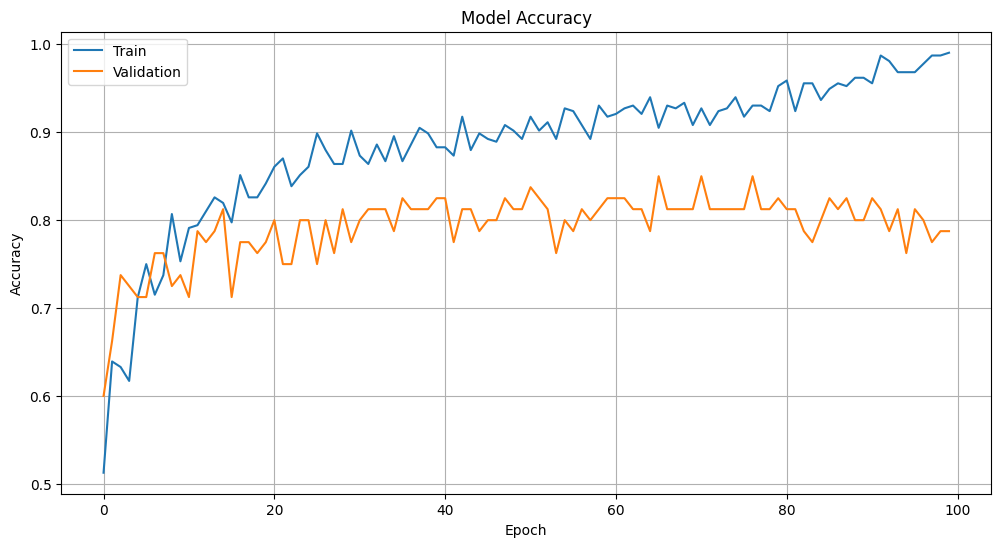

In [ ]:
# @title Plot Train and Validation Curves

plt.figure(figsize=(12, 6))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation','Test'], loc='upper left')
plt.grid(True)
plt.show()